In [60]:
import os
from pathlib import Path
import json
import torch
from nemo.collections.asr.models import EncDecSpeakerLabelModel
import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
# Identify the sound file and transcript
tld = Path(r"C:\Users\Somlab\Downloads")
fname = "audio1365983309"
audio_path = fname + ".16k.wav"
transcript_path = fname + ".transcript.json"

with open(tld / transcript_path, 'r', encoding='utf8') as f: 
    transcript = json.load(f)

In [ ]:
# Check speaker-level segments in the transcript
speaker = transcript[0]['speaker']
num_segments = len(transcript)
start_times, stop_times = [0], []
for i, t in enumerate(transcript):
    if t['speaker'] != speaker:
        start_times.append(t['start'])
        if i == 0 or i == num_segments:
            stop_times.append(t['end'])
        else:
            stop_times.append(transcript[i-1]['end'])
        speaker = t['speaker']

# Add the final timestampt
stop_times.append(transcript[-1]['end'])

In [ ]:
assert len(start_times) == len(stop_times), f"Uneven start and stop times"

# Get the encoder
enc_model = EncDecSpeakerLabelModel.from_pretrained(model_name="titanet_small").eval()
device = next(enc_model.parameters()).device
# load the whole audio file
sample_frequency = 16000
audio, _ = librosa.load(tld / audio_path, sr=sample_frequency)

In [ ]:
embeddings = []
for (start, stop) in zip(start_times, stop_times):
    # Get segment indices for audio file
    start_idx = int(start * sample_frequency)
    stop_idx = int(stop * sample_frequency)
    audio_tensor = torch.tensor(audio[start_idx:stop_idx], dtype=torch.float32).unsqueeze(0).to(device)
    audio_len = torch.tensor([audio_tensor.shape[1]], dtype=torch.int32).to(device)

    # Get the embedding from the encoding model
    with torch.no_grad():
        _, embedding = enc_model.forward(input_signal=audio_tensor, input_signal_length=audio_len)

    # Normalize and return to CPU
    embedding = embedding.squeeze(0).cpu().numpy()
    embeddings.append(embedding / np.linalg.norm(embedding))
    print(len(embeddings))

In [54]:
cosine_mat = np.zeros((len(embeddings), len(embeddings)))
for i in range(len(embeddings)):
    for j in range(len(embeddings)):
        cosine_mat[i,j] = np.dot(embeddings[i], embeddings[j])
distance_mat = 1-cosine_mat

In [55]:
feature_clusterer = AgglomerativeClustering(n_clusters=2, metric='precomputed', linkage='complete')
feature_labels = feature_clusterer.fit_predict(distance_mat)
feature_labels


array([0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

In [66]:
clust_model = AgglomerativeClustering(n_clusters=None, metric='precomputed', linkage='ward', distance_threshold=1)
speaker_predictions = clust_model.fit_predict(distance_mat)
speaker_predictions

ValueError: precomputed was provided as metric. Ward can only work with euclidean distances (i.e. 'euclidean' and 'l2').

{'icoord': [[35.0, 35.0, 45.0, 45.0],
  [25.0, 25.0, 40.0, 40.0],
  [15.0, 15.0, 32.5, 32.5],
  [65.0, 65.0, 75.0, 75.0],
  [55.0, 55.0, 70.0, 70.0],
  [95.0, 95.0, 105.0, 105.0],
  [85.0, 85.0, 100.0, 100.0],
  [62.5, 62.5, 92.5, 92.5],
  [23.75, 23.75, 77.5, 77.5],
  [125.0, 125.0, 135.0, 135.0],
  [115.0, 115.0, 130.0, 130.0],
  [155.0, 155.0, 165.0, 165.0],
  [145.0, 145.0, 160.0, 160.0],
  [122.5, 122.5, 152.5, 152.5],
  [50.625, 50.625, 137.5, 137.5],
  [5.0, 5.0, 94.0625, 94.0625],
  [195.0, 195.0, 205.0, 205.0],
  [185.0, 185.0, 200.0, 200.0],
  [255.0, 255.0, 265.0, 265.0],
  [245.0, 245.0, 260.0, 260.0],
  [235.0, 235.0, 252.5, 252.5],
  [225.0, 225.0, 243.75, 243.75],
  [215.0, 215.0, 234.375, 234.375],
  [192.5, 192.5, 224.6875, 224.6875],
  [175.0, 175.0, 208.59375, 208.59375],
  [285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [315.0, 315.0, 325.0, 325.0],
  [305.0, 305.0, 320.0, 320.0],
  [345.0, 345.0, 355.0, 355.0],
  [335.0, 335.0, 350.0, 350.0],
  [365

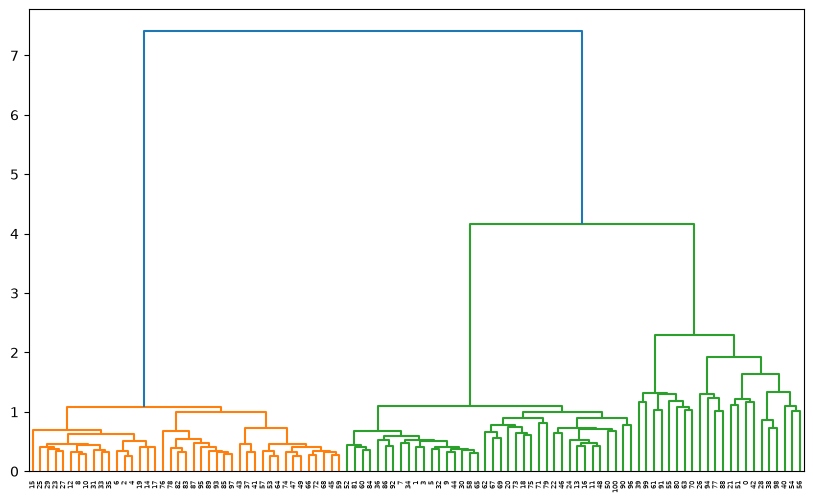

In [62]:
embedding_mat = np.array(embeddings)
Z = linkage(embedding_mat, method='ward')
plt.figure(figsize=(10, 6))
dendrogram(Z)